In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD THE EARTHQUAKE DATASET
# ============================================================

# CSV file location
csv_path = r"/content/earthquake_data.csv"

df = pd.read_csv(csv_path)

# Display first 5 records
print("First 5 Records")
print(df.head())

First 5 Records
                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  longitude                  location con

In [4]:
# ============================================================
# 2. DATASET INFORMATION
# ============================================================

print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      782 non-null    object 
 1   magnitude  782 non-null    float64
 2   date_time  782 non-null    object 
 3   cdi        782 non-null    int64  
 4   mmi        782 non-null    int64  
 5   alert      415 non-null    object 
 6   tsunami    782 non-null    int64  
 7   sig        782 non-null    int64  
 8   net        782 non-null    object 
 9   nst        782 non-null    int64  
 10  dmin       782 non-null    float64
 11  gap        782 non-null    float64
 12  magType    782 non-null    object 
 13  depth      782 non-null    float64
 14  latitude   782 non-null    float64
 15  longitude  782 non-null    float64
 16  location   777 non-null    object 
 17  continent  206 non-null    object 
 18  country    484 non-null    object 
dtypes: float64(6), int64(5), obje

In [5]:
# ============================================================
# 3. STATISTICAL SUMMARY
# ============================================================

print("\nStatistical Summary")
print(df.describe(include="all"))


Statistical Summary
           title   magnitude         date_time         cdi         mmi  alert  \
count        782  782.000000               782  782.000000  782.000000    415   
unique       768         NaN               773         NaN         NaN      4   
top     M 6.9 -          NaN  11-01-2022 12:39         NaN         NaN  green   
freq           3         NaN                 3         NaN         NaN    325   
mean         NaN    6.941125               NaN    4.333760    5.964194    NaN   
std          NaN    0.445514               NaN    3.169939    1.462724    NaN   
min          NaN    6.500000               NaN    0.000000    1.000000    NaN   
25%          NaN    6.600000               NaN    0.000000    5.000000    NaN   
50%          NaN    6.800000               NaN    5.000000    6.000000    NaN   
75%          NaN    7.100000               NaN    7.000000    7.000000    NaN   
max          NaN    9.100000               NaN    9.000000    9.000000    NaN   

      

In [6]:
# ============================================================
# 4. DISPLAY COLUMN NAMES
# ============================================================

print("\nColumn Names")
print(df.columns)



Column Names
Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')


In [8]:
# ============================================================
# 5. CONVERT CSV DATA TO JSON
# ============================================================

json_path = r"/content/earthquake_data.json"

df.to_json(
    json_path,
    orient="records",
    indent=4
)

print("\nJSON file created successfully!")


JSON file created successfully!


In [9]:
# ============================================================
# 6. READ DATA FROM JSON
# ============================================================

df_json = pd.read_json(json_path)

print("\nFirst 5 Records from JSON")
print(df_json.head())

print("\nJSON Dataset Information")
df_json.info()

print("\nJSON Statistical Summary")
print(df_json.describe(include="all"))



First 5 Records from JSON
                                          title  magnitude  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9   
2                                      M 7.0 -         7.0   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3   
4                                      M 6.6 -         6.6   

            date_time  cdi  mmi  alert  tsunami  sig net  nst   dmin   gap  \
0 2022-11-22 02:03:00    8    7  green        1  768  us  117  0.509  17.0   
1 2022-11-18 13:37:00    4    4  green        0  735  us   99  2.229  34.0   
2 2022-12-11 07:09:00    3    3  green        1  755  us  147  3.125  18.0   
3 2022-11-11 10:48:00    5    5  green        1  833  us  149  1.865  21.0   
4 2022-09-11 10:14:00    0    2  green        1  670  us  131  4.998  27.0   

  magType    depth  latitude  longitude                  location continent  \
0     mww   14.000   -9.7963    159.596  Malango, So

In [11]:
# ============================================================
# 7. EXPORT DATA TO SQLITE DATABASE
# ============================================================

db_path = r"/content/earthquake_data.db"

conn = sqlite3.connect(db_path)

df.to_sql(
    "earthquake_data",
    conn,
    if_exists="replace",
    index=False
)

print("\nData exported to SQLite successfully!")

conn.close()


Data exported to SQLite successfully!


In [12]:
# ============================================================
# 8. READ DATA FROM SQLITE DATABASE
# ============================================================

conn = sqlite3.connect(db_path)

df_sql = pd.read_sql(
    "SELECT * FROM earthquake_data",
    conn
)

print("\nFirst 5 Records from SQLite")
print(df_sql.head())

print("\nSQLite Dataset Information")
df_sql.info()

print("\nSQLite Statistical Summary")
print(df_sql.describe(include="all"))

conn.close()


First 5 Records from SQLite
                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  longitude                 

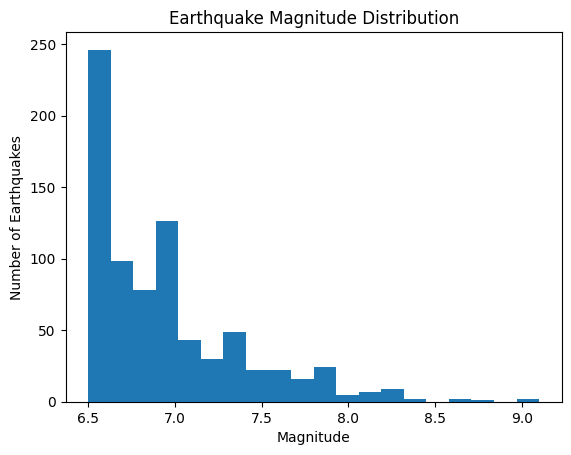

In [13]:
# ============================================================
# 9. EARTHQUAKE MAGNITUDE DISTRIBUTION
# ============================================================

plt.hist(df["magnitude"], bins=20)

plt.title("Earthquake Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")

plt.show()

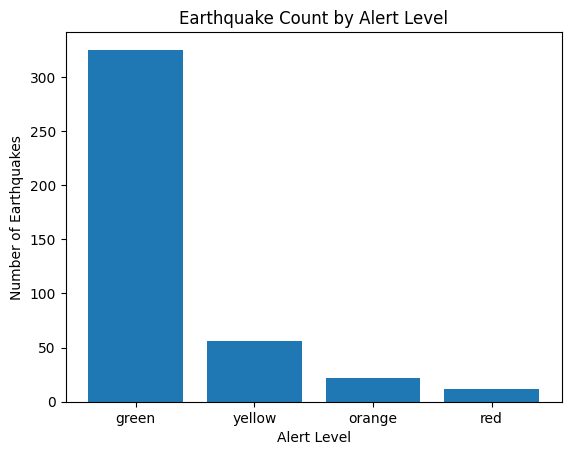

In [14]:
# ============================================================
# 10. EARTHQUAKE COUNT BY ALERT LEVEL
# ============================================================

alert_counts = df["alert"].value_counts()

plt.bar(alert_counts.index.astype(str), alert_counts.values)

plt.title("Earthquake Count by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Number of Earthquakes")

plt.show()

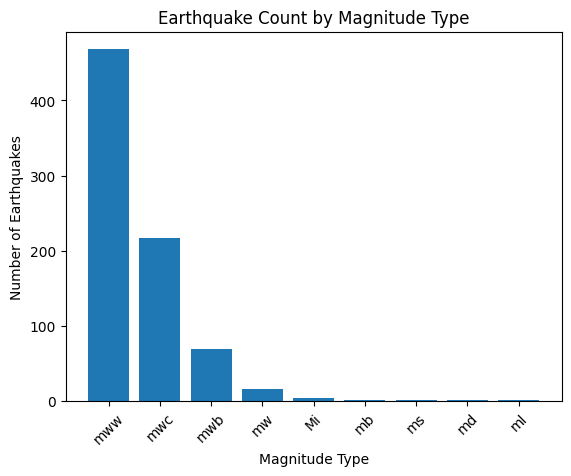

In [15]:

# ============================================================
# 11. EARTHQUAKE COUNT BY MAGNITUDE TYPE
# ============================================================

magtype_counts = df["magType"].value_counts()

plt.bar(magtype_counts.index.astype(str), magtype_counts.values)

plt.title("Earthquake Count by Magnitude Type")
plt.xlabel("Magnitude Type")
plt.ylabel("Number of Earthquakes")

plt.xticks(rotation=45)

plt.show()

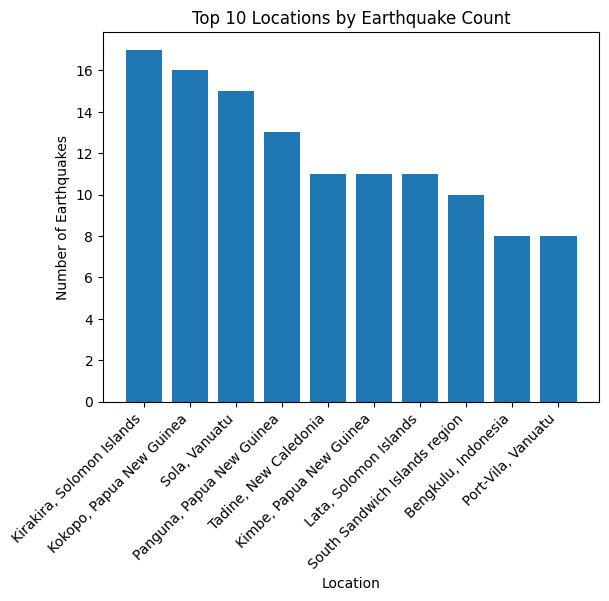

In [16]:
# ============================================================
# 12. TOP 10 LOCATIONS WITH MOST EARTHQUAKES
# ============================================================

location_counts = df["location"].value_counts().head(10)

plt.bar(location_counts.index.astype(str), location_counts.values)

plt.title("Top 10 Locations by Earthquake Count")
plt.xlabel("Location")
plt.ylabel("Number of Earthquakes")

plt.xticks(rotation=45, ha="right")

plt.show()



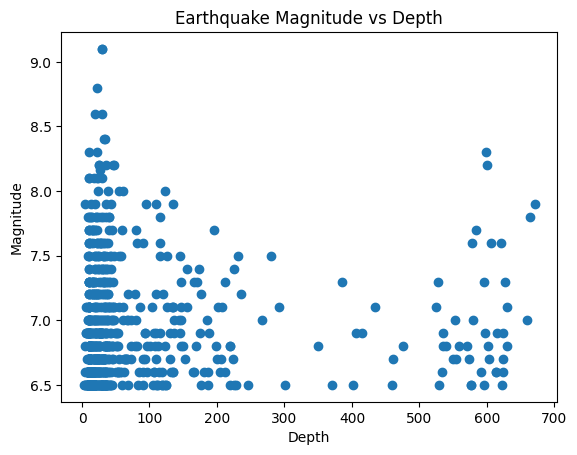

In [17]:
# ============================================================
# 13. MAGNITUDE VS DEPTH
# ============================================================

plt.scatter(df["depth"], df["magnitude"])

plt.title("Earthquake Magnitude vs Depth")
plt.xlabel("Depth")
plt.ylabel("Magnitude")

plt.show()